# APOP_Glu — SpecParam / FOOOF

**a) Parameterisation.** For every recording in `preprocessed_BIDS`:

1. Load the preprocessed continuous data (`.set`), drop the EOG channels
2. PSD per channel — Welch, 2 s Hann windows, 50 % overlap, in µV²/Hz
3. Fit a spectral model per channel → `flattened_ch`, `offset_ch`, `exponent_ch`, `peaks_ch`, `r_squared_ch`, `error_ch`
4. Global fit on the channel-averaged PSD → `offset`, `exponent`, `peaks`, `r_squared`, `error` + plotting arrays
5. Band peaks — highest peak within each of the D/T/A/B/G ranges (CF, PW, BW)
6. Save `<recording>_parameterised.mat`, mirroring the input BIDS tree
7. Append the global results, plus per-recording quality metrics, to one overview CSV

Quality metrics in the CSV, beyond the fit parameters:

| | |
|---|---|
| how much data | `Duration_s` (as loaded, i.e. post-`clean_rawdata`), `N_Windows`, `N_Windows_Possible`, `Pct_Windows_Kept`, `N_Boundaries`, `N_Channels`, `Srate` |
| fit quality | `R_Squared`, `Error_MAE`, `Mean_R2_Ch`, `Min_R2_Ch`, `Mean_Error_Ch`, `N_Ch_R2_Below`, `Ch_R2_Below` |
| spread across channels | `SD_Exponent_Ch`, `Min_Exponent_Ch`, `Max_Exponent_Ch` |
| within-recording reliability | `Exponent_H1`, `Exponent_H2`, `Exponent_SplitDiff` — the same fit on the first vs. second half of the windows |
| artefact proxies | `Line50_dB` (50 Hz above its neighbours), `EMG_Flat_30_45` (flattened power 30–45 Hz), `LowEdge_MAE` (model residual over the lowest 2 Hz of the fit) |

**b) Quality of fit.**

1. Merges the preprocessing log — original length, data / channels / ICs removed, EOG correlations
2. Describes everything globally and per condition (2 PrePost × 2 EyeState × 4 Drug); Checks whether cleaning was comparable across arms 
3. Flags recordings against every threshold
4. Plots the mean spectrum, aperiodic fit and flattened spectrum

Recordings that already have a `.mat`, and `.set` files written in the last minute are skipped

In [1]:
import re, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from mne.time_frequency import psd_array_welch
from scipy.io import loadmat, savemat
from specparam import SpectralModel

mne.set_log_level("ERROR")
warnings.filterwarnings("ignore", category=RuntimeWarning)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False, "axes.spines.right": False})
rng = np.random.default_rng(0)

## 0. Settings

Everything that can be changed lives here.

In [2]:
# 0.1 Paths (on the machine that runs the preprocessing)
PREPROC_ROOT = Path(r"D:\Linus\APOP_Glu\preprocessed2_BIDS")
OUT_ROOT     = Path(r"D:\Linus\APOP_Glu\parameterised2_BIDS")
COND_FILE    = Path("APOP_Glu_Conditions.csv")          # next to this notebook
CSV_NAME     = "APOP_Glu_specparam_results.csv"         # written into OUT_ROOT
PREPROC_LOG  = PREPROC_ROOT / "APOP_Glu_preprocessing_log.csv"   # merged in part b

# 0.2 PSD parameters (Welch)
WIN_SEC            = 2.0            # Hann window length -> 0.5 Hz resolution
OVERLAP            = 0.5            # 50 %
PSD_FMIN, PSD_FMAX = 0.5, 80.0      # stored range = the preprocessing passband
DROP_CHANNELS      = ["EOG_L", "EOG_R"]
EPOCH_REJECT_UV    = 150            # -> drop 2 s windows exceeding +-150 uV
MIN_FILE_AGE_S     = 60             # ignore .set files written in the last minute

# 0.3 SpecParam parameters
FIT_RANGE = (2.0, 45.0)             # below 50 Hz line noise; 1 Hz is affected by 0.5 Hz highpass
SPECPARAM = dict(
    peak_width_limits = [1.0, 12.0],   # lower >= 2x freq resolution; specparam default upper is 12
    max_n_peaks       = 6,
    min_peak_height   = 0.05,
    peak_threshold    = 2.0,
    aperiodic_mode    = "fixed",       # "knee" if the log-log spectrum bends inside FIT_RANGE
)

# 0.4 Quality-control metrics / thresholds
R2_FLAG     = 0.90                  # flag fits below this
MIN_WINDOWS = 40                    # slope reliability needs ~30-40 usable windows
LINE_FREQ   = 50.0                  # residual line noise is measured here
EMG_BAND    = (30.0, 45.0)          # flattened power here = residual muscle proxy
LOW_EDGE_HZ = 2.0                   # model residual over FIT_RANGE[0]..this = highpass edge

# 0.5 Frequency bands (Hz)
BANDS = {"Delta": (FIT_RANGE[0], 4.0), "Theta": (4.0, 8.0), "Alpha": (8.0, 13.0),
         "Beta": (13.0, 30.0), "Gamma": (30.0, FIT_RANGE[1])}

# 0.6 Plotting
DRUG_ORDER  = ["Placebo", "Perampanel", "Dextromethorphan", "Nimodipine"]
DRUG_COLORS = {"Placebo": "#0072B2", "Perampanel": "#D55E00",
               "Dextromethorphan": "#009E73", "Nimodipine": "#E69F00"}

## Helpers

In [3]:
FNAME_RE = re.compile(r"^sub-(?P<subject>[^_]+)_ses-day(?P<day>\d+)_task-rest"
                      r"(?P<eyestate>EO|EC)_acq-(?P<prepost>pre|post)_eeg_preprocessed$")

def load_conditions(path):
    """{(Subject, Day): (Condition, Drug)} from APOP_Glu_Conditions.csv."""
    t = pd.read_csv(path, encoding="utf-8-sig")          # strip BOM
    t.columns = [c.strip() for c in t.columns]           # 'Condition ' -> 'Condition'
    return {(str(r.Subject).strip(), int(r.Day)): (r.Condition, r.Drug)
            for r in t.itertuples()}

def compute_psd(raw):
    """Welch PSD per 2 s window, uV^2/Hz, skipping windows that span an ASR splice.

    Returns psds (window x channel x frequency), freqs, and how many windows the
    recording could have yielded / how many splices it contains."""
    sfreq = raw.info["sfreq"]
    is_b = np.array([d.lower() == "boundary" for d in raw.annotations.description], bool)
    raw.set_annotations(mne.Annotations(raw.annotations.onset[is_b], 1 / sfreq, "BAD_boundary"))
    ep = mne.make_fixed_length_epochs(raw, duration=WIN_SEC, overlap=WIN_SEC * OVERLAP,
                                      preload=True, reject_by_annotation=True)
    if EPOCH_REJECT_UV:
        ep.drop_bad(reject=dict(eeg=EPOCH_REJECT_UV * 1e-6))
    n = int(round(WIN_SEC * sfreq))
    psds, freqs = psd_array_welch(ep.get_data() * 1e6, sfreq, fmin=PSD_FMIN, fmax=PSD_FMAX,
                                  n_fft=n, n_per_seg=n, window="hann", average="mean")
    return psds, freqs, len(ep.drop_log), int(is_b.sum())

def band_mean(freqs, values, lo, hi):
    return float(values[(freqs >= lo) & (freqs <= hi)].mean())

def line_residual_db(freqs, psd, f0=LINE_FREQ):
    """Power at the line frequency above the surrounding bins, in dB.
    ~0 means Zapline/CleanLine removed it; a few dB means it is still there."""
    peak = psd[np.abs(freqs - f0) <= 0.5].max()
    side = psd[(np.abs(freqs - f0) >= 2.0) & (np.abs(freqs - f0) <= 5.0)].mean()
    return float(10 * np.log10(peak / side))

def fit_spectrum(freqs, spectrum):
    fm = SpectralModel(**SPECPARAM, verbose=False)
    fm.fit(freqs, spectrum, list(FIT_RANGE))
    return fm

def as_peaks(p):
    """get_params('peak') -> always an (n_peaks, 3) array of [CF, PW, BW]."""
    p = np.asarray(p, float)
    return p.reshape(-1, 3) if p.size else np.empty((0, 3))

def biggest_peak(peaks, lo, hi):
    """[CF, PW, BW] of the highest-power peak in the band, NaNs if there is none."""
    sel = peaks[(peaks[:, 0] >= lo) & (peaks[:, 0] <= hi)]
    return sel[np.argmax(sel[:, 1])] if len(sel) else np.full(3, np.nan)

def aperiodic_fit(fm):
    """Modelled aperiodic component, log10 power over the fitted range.
    NB: fm.get_data('aperiodic') is the *data* with peaks removed, not this."""
    return fm.results.model.get_component("aperiodic")

def periodic_fit(fm):
    return fm.results.model.get_component("peak")

def full_fit(fm):
    return fm.results.model.get_component("full")

def to_cell(arrays):
    """List of arrays -> object array, so savemat writes a MATLAB cell."""
    c = np.empty(len(arrays), dtype=object)
    for i, a in enumerate(arrays):
        c[i] = np.asarray(a, float)
    return c

## 1.–6. Parameterise every preprocessed recording

One `.mat` per recording, written to `parameterised_BIDS/sub-<ID>/ses-day<N>/<pre|post>/<EO|EC>/`.
Errors are collected per file rather than stopping the loop.

In [4]:
CONDITIONS = load_conditions(COND_FILE)
files = sorted(PREPROC_ROOT.glob("sub-*/ses-day*/*/*/*_preprocessed.set"))
print(f"{len(files)} preprocessed file(s) under {PREPROC_ROOT}")

rows, skipped, failed = [], [], []

for f in files:
    out_file = (OUT_ROOT / f.parent.relative_to(PREPROC_ROOT) /
                f.name.replace("_preprocessed.set", "_parameterised.mat"))
    ent = FNAME_RE.match(f.stem)
    if ent is None:
        failed.append((f.name, "filename does not match the BIDS pattern")); continue
    if out_file.exists():
        skipped.append(f.name); continue
    if time.time() - f.stat().st_mtime < MIN_FILE_AGE_S:
        skipped.append(f"{f.name} (still being written)"); continue

    try:
        base = f.stem.replace("_preprocessed", "")
        sub, day = ent["subject"], int(ent["day"])
        prepost, eyestate = ent["prepost"], ent["eyestate"]
        condition, drug = CONDITIONS.get((sub, day), ("undefined", "undefined"))

        # 1. load, drop EOG
        raw = mne.io.read_raw_eeglab(f, preload=True)
        raw.drop_channels([c for c in DROP_CHANNELS if c in raw.ch_names])
        raw.pick("eeg")

        # 2. PSD
        duration_s = raw.n_times / raw.info["sfreq"]
        psds, freqs, n_possible, n_boundaries = compute_psd(raw)
        psd, n_windows = psds.mean(axis=0), len(psds)
        mask = (freqs >= FIT_RANGE[0]) & (freqs <= FIT_RANGE[1])
        ffit = freqs[mask]

        # 3. channelwise fits
        fms = [fit_spectrum(freqs, psd[i]) for i in range(psd.shape[0])]
        flattened_ch = np.array([np.log10(psd[i, mask]) - aperiodic_fit(fm)
                                 for i, fm in enumerate(fms)])
        r2_ch = np.array([fm.get_metrics("gof_rsquared") for fm in fms])
        err_ch = np.array([fm.get_metrics("error_mae") for fm in fms])
        exp_ch = np.array([fm.get_params("aperiodic", "exponent") for fm in fms])
        low_ch = [c for c, r in zip(raw.ch_names, r2_ch) if r < R2_FLAG]

        # 4. global fit
        psd_global = psd.mean(axis=0)
        fmg = fit_spectrum(freqs, psd_global)
        ap_fit = aperiodic_fit(fmg)
        flattened_global = np.log10(psd_global[mask]) - ap_fit

        # 5. band peaks
        peaks = as_peaks(fmg.get_params("peak"))
        band_peak = {b: biggest_peak(peaks, *r) for b, r in BANDS.items()}

        # 5b. performance metrics
        # split-half: same fit on the first and second half of the windows
        h = n_windows // 2
        if h >= 2:
            exp_h = [fit_spectrum(freqs, s).get_params("aperiodic", "exponent")
                     for s in (psds[:h].mean(axis=(0, 1)), psds[h:].mean(axis=(0, 1)))]
        else:
            exp_h = [np.nan, np.nan]
        resid = np.abs(np.log10(psd_global[mask]) - full_fit(fmg))   # |data - full model|

        # 6. save
        out_file.parent.mkdir(parents=True, exist_ok=True)
        savemat(out_file, {
            # design / provenance
            "filename": base, "subject": sub, "day": day, "prepost": prepost,
            "eyestate": eyestate, "condition": str(condition), "drug": str(drug),
            "srate": raw.info["sfreq"], "duration_s": duration_s,
            "total_windows": n_windows, "possible_windows": n_possible,
            "n_boundaries": n_boundaries,
            "fit_range": np.array(FIT_RANGE, float),
            "psd_window_sec": WIN_SEC, "psd_overlap": OVERLAP,
            "exponent_half1": exp_h[0], "exponent_half2": exp_h[1],
            # global model
            "offset": fmg.get_params("aperiodic", "offset"),
            "exponent": fmg.get_params("aperiodic", "exponent"),
            "peaks": peaks,
            "r_squared": fmg.get_metrics("gof_rsquared"),
            "error": fmg.get_metrics("error_mae"),
            **{f"global_peak_{b.lower()}": v for b, v in band_peak.items()},
            # plotting
            "power_spectrum": psd_global, "frequencies": freqs,
            "frequencies_fitted": freqs[mask], "aperiodic_fit": ap_fit,
            "periodic_fit": periodic_fit(fmg), "flattened_global": flattened_global,
            # channelwise
            "chanlabels": np.array(raw.ch_names, dtype=object),
            "psd_ch": psd, "flattened_ch": flattened_ch,
            "offset_ch": np.array([fm.get_params("aperiodic", "offset") for fm in fms]),
            "exponent_ch": exp_ch,
            "peaks_ch": to_cell([as_peaks(fm.get_params("peak")) for fm in fms]),
            "r_squared_ch": r2_ch, "error_ch": err_ch,
        })

        rows.append({
            "Filename": base, "Subject": sub, "Day": day, "PrePost": prepost,
            "EyeState": eyestate, "Condition": condition, "Drug": drug,
            # how much data went in
            "Duration_s": duration_s, "Srate": raw.info["sfreq"],
            "N_Channels": psd.shape[0], "N_Windows": n_windows,
            "N_Windows_Possible": n_possible,
            "Pct_Windows_Kept": 100 * n_windows / n_possible,
            "N_Boundaries": n_boundaries,
            # global model
            "Offset": fmg.get_params("aperiodic", "offset"),
            "Exponent": fmg.get_params("aperiodic", "exponent"),
            "R_Squared": fmg.get_metrics("gof_rsquared"),
            "Error_MAE": fmg.get_metrics("error_mae"), "N_Peaks": len(peaks),
            **{f"{b}_{p}": band_peak[b][i]
               for b in BANDS for i, p in enumerate(("CF", "PW", "BW"))},
            # spread of the fit across channels
            "Mean_R2_Ch": r2_ch.mean(), "Min_R2_Ch": r2_ch.min(),
            "Mean_Error_Ch": err_ch.mean(),
            "SD_Exponent_Ch": exp_ch.std(ddof=1), "Min_Exponent_Ch": exp_ch.min(),
            "Max_Exponent_Ch": exp_ch.max(),
            "N_Ch_R2_Below": len(low_ch), "Ch_R2_Below": "; ".join(low_ch),
            # within-recording reliability
            "Exponent_H1": exp_h[0], "Exponent_H2": exp_h[1],
            "Exponent_SplitDiff": abs(exp_h[0] - exp_h[1]),
            # artefact proxies
            "Line50_dB": line_residual_db(freqs, psd_global),
            "EMG_Flat_30_45": band_mean(ffit, flattened_global, *EMG_BAND),
            "LowEdge_MAE": band_mean(ffit, resid, FIT_RANGE[0], LOW_EDGE_HZ),
            "All_Peaks_CF_PW_BW": str(peaks.tolist()),
        })
        print(f"  ok   {base}  |  {n_windows} windows  |  exponent {rows[-1]['Exponent']:.2f}"
              f"  |  R2 {rows[-1]['R_Squared']:.3f}")

    except Exception as e:
        failed.append((f.name, repr(e)))
        print(f"  FAIL {f.name}: {e}")

print(f"\n{len(rows)} new | {len(skipped)} skipped | {len(failed)} failed")
for name, msg in failed:
    print("   ", name, "->", msg)

233 preprocessed file(s) under D:\Linus\APOP_Glu\preprocessed2_BIDS
  ok   sub-AK_ses-day1_task-restEC_acq-post_eeg  |  169 windows  |  exponent 1.63  |  R2 0.994
  ok   sub-AK_ses-day1_task-restEO_acq-post_eeg  |  209 windows  |  exponent 1.46  |  R2 0.996
  ok   sub-AK_ses-day1_task-restEC_acq-pre_eeg  |  231 windows  |  exponent 1.39  |  R2 0.994
  ok   sub-AK_ses-day1_task-restEO_acq-pre_eeg  |  191 windows  |  exponent 1.40  |  R2 0.996
  ok   sub-AK_ses-day2_task-restEC_acq-post_eeg  |  225 windows  |  exponent 1.26  |  R2 0.997
  ok   sub-AK_ses-day2_task-restEO_acq-post_eeg  |  188 windows  |  exponent 1.25  |  R2 0.997
  ok   sub-AK_ses-day2_task-restEC_acq-pre_eeg  |  223 windows  |  exponent 1.31  |  R2 0.996
  ok   sub-AK_ses-day2_task-restEO_acq-pre_eeg  |  216 windows  |  exponent 1.36  |  R2 0.998
  ok   sub-AK_ses-day3_task-restEC_acq-post_eeg  |  164 windows  |  exponent 1.48  |  R2 0.996
  ok   sub-AK_ses-day3_task-restEO_acq-post_eeg  |  163 windows  |  exponent 1.31

## 7. Overview CSV

New results are merged into `APOP_Glu_specparam_results.csv`; existing rows for a
recording are replaced, so the file stays current across re-runs.

In [5]:
OUT_ROOT.mkdir(parents=True, exist_ok=True)
csv_path = OUT_ROOT / CSV_NAME

old = pd.read_csv(csv_path) if csv_path.exists() else pd.DataFrame()
df = pd.concat([old, pd.DataFrame(rows)], ignore_index=True)
df = (df.drop_duplicates(subset="Filename", keep="last")
        .sort_values("Filename").reset_index(drop=True))
df.to_csv(csv_path, index=False)

print(f"{len(df)} recordings in {csv_path}")
df.head()

233 recordings in D:\Linus\APOP_Glu\parameterised2_BIDS\APOP_Glu_specparam_results.csv


,Filename,Subject,Day,PrePost,EyeState,Condition,Drug,Duration_s,Srate,N_Channels,...,Max_Exponent_Ch,N_Ch_R2_Below,Ch_R2_Below,Exponent_H1,Exponent_H2,Exponent_SplitDiff,Line50_dB,EMG_Flat_30_45,LowEdge_MAE,All_Peaks_CF_PW_BW
0,sub-AK_ses-day1_task-restEC_acq-post_eeg,AK,1,post,EC,1,Perampanel,193.880,1000.0,63,...,1.782936,0,,1.626760,1.624404,0.002355,-0.080560,-0.019093,0.237894,"[[9.096865839703215, 1.255950857432177, 1.7561..."
1,sub-AK_ses-day1_task-restEC_acq-pre_eeg,AK,1,pre,EC,1,Perampanel,242.140,1000.0,63,...,1.624795,0,,1.358447,1.416240,0.057793,-0.210675,-0.017736,0.183021,"[[9.888666887180715, 1.3031291725775231, 3.129..."
2,sub-AK_ses-day1_task-restEO_acq-post_eeg,AK,1,post,EO,1,Perampanel,222.433,1000.0,63,...,1.737610,0,,1.524687,1.412511,0.112177,-0.165150,-0.032189,0.208020,"[[9.244284546855301, 1.5505664839592848, 2.566..."
3,sub-AK_ses-day1_task-restEO_acq-pre_eeg,AK,1,pre,EO,1,Perampanel,214.800,1000.0,63,...,1.721907,0,,1.384505,1.419217,0.034712,-0.455876,-0.020029,0.120243,"[[10.334828602463208, 1.0193485376169482, 2.26..."
4,sub-AK_ses-day2_task-restEC_acq-post_eeg,AK,2,post,EC,2,Dextromethorphan,237.296,1000.0,63,...,1.647392,0,,1.267690,1.245443,0.022247,-0.193406,-0.012340,0.165581,"[[9.76658364390047, 1.251426176192575, 2.19991..."


---
# b) Quality of fit

## 1. Load, and merge the preprocessing log

`Duration_s` is the recording **as loaded here**, i.e. after `clean_rawdata` removed bad
windows. The original length is `Loaded_Seconds` in the preprocessing log, which is merged
in below — together with how much data, how many channels and how many ICs each recording
lost, so cleaning can be compared across Pre/Post and drugs.

In [6]:
df = pd.read_csv(OUT_ROOT / CSV_NAME)
drugs = [d for d in DRUG_ORDER if d in set(df.Drug)]
print(f"{len(df)} recordings, {df.Subject.nunique()} subjects")

qc = df.copy()
if PREPROC_LOG.exists():
    log = pd.read_csv(PREPROC_LOG)
    log["Filename"] = log["Raw_Filename"].astype(str).str.replace(r"\.vhdr$", "", regex=True)
    keep = ["Filename", "Status", "Loaded_Seconds", "Removed_Seconds", "Removed_Channels_N",
            "ICA_Rank", "Total_Removed_ICs", "Eye_Rejected_ICs", "Muscle_Rejected_ICs",
            "EOG_Corr_Before", "EOG_Corr_After", "Max_IC_EOG_Corr"]
    log = log[[c for c in keep if c in log.columns]].drop_duplicates("Filename", keep="last")
    qc = qc.merge(log, on="Filename", how="left")
    qc["Pct_Seconds_Removed"] = 100 * qc.Removed_Seconds / qc.Loaded_Seconds
    print(f"preprocessing log merged ({qc.Loaded_Seconds.notna().sum()} matched)")
else:
    print(f"no preprocessing log at {PREPROC_LOG} — cleaning columns unavailable")

233 recordings, 16 subjects
preprocessing log merged (233 matched)


## 2. Descriptives

Fit quality, how much data went in, and the artefact proxies — overall and per condition.

In [7]:
FIT_COLS  = ["Exponent", "Offset", "R_Squared", "Error_MAE", "N_Peaks",
             "SD_Exponent_Ch", "Exponent_SplitDiff"]
DATA_COLS = ["Duration_s", "N_Windows", "Pct_Windows_Kept", "N_Boundaries",
             "Line50_dB", "EMG_Flat_30_45", "LowEdge_MAE"]
display(qc[FIT_COLS + DATA_COLS].describe().round(3))

by_condition = (qc.groupby(["Drug", "PrePost", "EyeState"])
                  .agg(N=("R_Squared", "size"),
                       R2_mean=("R_Squared", "mean"), R2_min=("R_Squared", "min"),
                       MAE_mean=("Error_MAE", "mean"),
                       Exp_mean=("Exponent", "mean"), Exp_sd=("Exponent", "std"),
                       SplitDiff_mean=("Exponent_SplitDiff", "mean"),
                       Dur_mean=("Duration_s", "mean"),
                       Win_mean=("N_Windows", "mean"), Win_min=("N_Windows", "min"),
                       PctKept_mean=("Pct_Windows_Kept", "mean")).round(3))
display(by_condition)

,Exponent,Offset,R_Squared,Error_MAE,N_Peaks,SD_Exponent_Ch,Exponent_SplitDiff,Duration_s,N_Windows,Pct_Windows_Kept,N_Boundaries,Line50_dB,EMG_Flat_30_45,LowEdge_MAE
count,233.000,233.000,233.000,233.000,233.000,233.000,233.000,233.000,233.000,233.000,233.000,233.000,233.000,233.000
mean,1.377,0.799,0.994,0.034,3.618,0.183,0.087,193.923,170.644,88.195,13.545,-0.296,-0.006,0.141
std,0.232,0.302,0.004,0.012,1.124,0.054,0.088,49.150,51.134,11.136,12.612,0.210,0.018,0.094
min,0.618,-0.054,0.972,0.013,1.000,0.057,0.000,51.269,26.000,35.096,1.000,-0.831,-0.040,0.000
25%,1.227,0.594,0.992,0.027,3.000,0.145,0.026,152.566,136.000,85.455,5.000,-0.412,-0.017,0.066
50%,1.372,0.799,0.994,0.033,4.000,0.177,0.061,205.760,171.000,91.416,10.000,-0.305,-0.010,0.135
75%,1.533,0.994,0.996,0.039,4.000,0.216,0.118,235.699,214.000,95.547,17.000,-0.190,0.000,0.197
max,2.059,1.632,0.998,0.090,6.000,0.371,0.771,335.020,324.000,99.614,78.000,1.259,0.121,0.399


N  R2_mean  R2_min  MAE_mean  Exp_mean  \
Drug             PrePost EyeState                                            
Dextromethorphan post    EC        14    0.992   0.976     0.037     1.280   
                         EO        14    0.993   0.978     0.028     1.203   
                 pre     EC        14    0.993   0.980     0.037     1.421   
                         EO        14    0.995   0.991     0.027     1.335   
Nimodipine       post    EC        15    0.993   0.988     0.041     1.497   
                         EO        15    0.994   0.988     0.034     1.335   
                 pre     EC        12    0.994   0.985     0.035     1.479   
                         EO        14    0.993   0.990     0.035     1.383   
Perampanel       post    EC        14    0.995   0.993     0.034     1.607   
                         EO        15    0.994   0.986     0.037     1.336   
                 pre     EC        15    0.993   0.972     0.037     1.457   
                         EO        15    0.993   0.982     0.033     1.270   
Placebo          post    EC        16    0.993   0.985     0.037     1.399   
                         EO        15    0.994   0.980     0.033     1.312   
                 pre     EC        15    0.994   0.986     0.034     1.401   
                         EO        16    0.994   0.986     0.031     1.333   

                                   Exp_sd  SplitDiff_mean  Dur_mean  Win_mean  \
Drug             PrePost EyeState                                               
Dextromethorphan post    EC         0.196           0.060   198.885   185.857   
                         EO         0.219           0.054   187.780   150.929   
                 pre     EC         0.235           0.115   208.623   191.643   
                         EO         0.198           0.107   182.857   146.929   
Nimodipine       post    EC         0.188           0.094   211.289   200.733   
                         EO         0.193           0.064   193.336   172.533   
                 pre     EC         0.265           0.096   211.415   196.167   
                         EO         0.174           0.070   204.010   173.857   
Perampanel       post    EC         0.224           0.111   195.136   170.857   
                         EO         0.173           0.090   173.689   145.467   
                 pre     EC         0.261           0.103   199.836   183.800   
                         EO         0.194           0.090   170.839   135.200   
Placebo          post    EC         0.252           0.089   191.253   172.188   
                         EO         0.242           0.063   196.001   168.867   
                 pre     EC         0.277           0.098   194.116   181.667   
                         EO         0.176           0.082   188.639   159.125   

                                   Win_min  PctKept_mean  
Drug             PrePost EyeState                         
Dextromethorphan post    EC             96        93.827  
                         EO             76        81.069  
                 pre     EC            102        91.965  
                         EO             55        81.796  
Nimodipine       post    EC            117        95.465  
                         EO            104        89.833  
                 pre     EC            144        93.617  
                         EO            105        86.492  
Perampanel       post    EC             68        87.897  
                         EO             26        83.377  
                 pre     EC            101        92.310  
                         EO             43        79.162  
Placebo          post    EC             89        90.241  
                         EO             87        86.202  
                 pre     EC             56        93.649  
                         EO             82        84.979

### Is cleaning comparable across conditions?

Independent, fully data-driven cleaning per recording is only harmless if it removed
comparable amounts everywhere. If the sedating arms lost systematically more data,
more channels or more ICs, that is a confound on the exponent in its own right.

In [8]:
CLEAN_COLS = [c for c in ["Loaded_Seconds", "Pct_Seconds_Removed", "Removed_Channels_N",
                          "Total_Removed_ICs", "Eye_Rejected_ICs", "ICA_Rank",
                          "EOG_Corr_After", "Pct_Windows_Kept"] if c in qc.columns]
if CLEAN_COLS:
    display(qc.groupby(["Drug", "PrePost"])[CLEAN_COLS].mean().round(2))

Loaded_Seconds  Pct_Seconds_Removed  \
Drug             PrePost                                        
Dextromethorphan post             210.59                 7.99   
                 pre              216.35                 9.90   
Nimodipine       post             213.02                 5.26   
                 pre              223.37                 6.78   
Perampanel       post             214.90                14.17   
                 pre              204.37                 9.20   
Placebo          post             212.88                 9.24   
                 pre              207.82                 8.08   

                          Removed_Channels_N  Total_Removed_ICs  \
Drug             PrePost                                          
Dextromethorphan post                   2.68              12.64   
                 pre                    2.71               8.32   
Nimodipine       post                   2.23               7.57   
                 pre                    2.65               8.69   
Perampanel       post                   2.21               7.45   
                 pre                    2.23               8.37   
Placebo          post                   2.29               8.52   
                 pre                    2.81               8.48   

                          Eye_Rejected_ICs  ICA_Rank  EOG_Corr_After  \
Drug             PrePost                                               
Dextromethorphan post                 2.18     59.32            0.62   
                 pre                  1.79     59.29            0.66   
Nimodipine       post                 1.63     59.77            0.67   
                 pre                  1.96     59.35            0.65   
Perampanel       post                 2.10     59.79            0.71   
                 pre                  1.97     59.77            0.64   
Placebo          post                 1.74     59.71            0.70   
                 pre                  1.65     59.19            0.68   

                          Pct_Windows_Kept  
Drug             PrePost                    
Dextromethorphan post                87.45  
                 pre                 86.88  
Nimodipine       post                92.65  
                 pre                 89.78  
Perampanel       post                85.56  
                 pre                 85.74  
Placebo          post                88.29  
                 pre                 89.17

## 3. Flags

In [9]:
pd.set_option("display.max_colwidth", None)   # else the channel list is truncated with "..."

BASE = ["Filename", "Drug", "PrePost", "EyeState"]
checks = {
    f"global R2 < {R2_FLAG}":              (qc.R_Squared < R2_FLAG,
                                            ["R_Squared", "Error_MAE"]),
    f">= 1 channel R2 < {R2_FLAG}":        (qc.N_Ch_R2_Below > 0,
                                            ["N_Ch_R2_Below", "Min_R2_Ch", "Ch_R2_Below"]),
    f"< {MIN_WINDOWS} windows":            (qc.N_Windows < MIN_WINDOWS,
                                            ["N_Windows", "Duration_s"]),
    "> 25 % of windows dropped":           (qc.Pct_Windows_Kept < 75,
                                            ["N_Windows", "N_Windows_Possible", "Pct_Windows_Kept"]),
    "exponent varies > 0.5 across ch":     ((qc.Max_Exponent_Ch - qc.Min_Exponent_Ch) > 0.5,
                                            ["Min_Exponent_Ch", "Max_Exponent_Ch", "SD_Exponent_Ch"]),
    "split-half exponent differs > 0.2":   (qc.Exponent_SplitDiff > 0.2,
                                            ["Exponent_H1", "Exponent_H2", "Exponent_SplitDiff"]),
    f"residual {LINE_FREQ:.0f} Hz > 3 dB": (qc.Line50_dB > 3, ["Line50_dB"]),
    "flattened 30-45 Hz > 0.1":            (qc.EMG_Flat_30_45 > 0.1, ["EMG_Flat_30_45"]),
}
for label, (m, extra) in checks.items():
    m = m.fillna(False)
    print(f"{int(m.sum()):3d}  {label}")
    if m.any():
        display(qc.loc[m, BASE + extra].round(3))

  0  global R2 < 0.9
 27  >= 1 channel R2 < 0.9


,Filename,Drug,PrePost,EyeState,N_Ch_R2_Below,Min_R2_Ch,Ch_R2_Below
17,sub-AM_ses-day1_task-restEC_acq-pre_eeg,Placebo,pre,EC,1,0.733,FC3
18,sub-AM_ses-day1_task-restEO_acq-post_eeg,Placebo,post,EO,3,0.324,O1; Iz; Oz
23,sub-AM_ses-day2_task-restEO_acq-pre_eeg,Perampanel,pre,EO,1,0.860,F8
26,sub-AM_ses-day3_task-restEO_acq-post_eeg,Dextromethorphan,post,EO,1,0.742,CP6
35,sub-DB_ses-day1_task-restEO_acq-pre_eeg,Perampanel,pre,EO,1,0.848,TP10
38,sub-DB_ses-day2_task-restEO_acq-post_eeg,Dextromethorphan,post,EO,2,0.681,T7; TP10
45,sub-DB_ses-day4_task-restEO_acq-pre_eeg,Placebo,pre,EO,2,0.543,C4; TP8
54,sub-DN_ses-day1_task-restEC_acq-post_eeg,Dextromethorphan,post,EC,2,0.890,FC5; FT7
55,sub-DN_ses-day1_task-restEC_acq-pre_eeg,Dextromethorphan,pre,EC,6,0.568,F3; C3; T7; FC6; FC3; F5
56,sub-DN_ses-day1_task-restEO_acq-post_eeg,Dextromethorphan,post,EO,9,0.432,C3; F7; F8; FC6; CP5; FC3; CP3; F6; C5


  1  < 40 windows


,Filename,Drug,PrePost,EyeState,N_Windows,Duration_s
195,sub-SR_ses-day3_task-restEO_acq-post_eeg,Perampanel,post,EO,26,51.269


 26  > 25 % of windows dropped


...

,Filename,Drug,PrePost,EyeState,Min_Exponent_Ch,Max_Exponent_Ch,SD_Exponent_Ch
1,sub-AK_ses-day1_task-restEC_acq-pre_eeg,Perampanel,pre,EC,1.090,1.625,0.126
2,sub-AK_ses-day1_task-restEO_acq-post_eeg,Perampanel,post,EO,0.878,1.738,0.146
3,sub-AK_ses-day1_task-restEO_acq-pre_eeg,Perampanel,pre,EO,1.094,1.722,0.132
4,sub-AK_ses-day2_task-restEC_acq-post_eeg,Dextromethorphan,post,EC,0.937,1.647,0.169
5,sub-AK_ses-day2_task-restEC_acq-pre_eeg,Dextromethorphan,pre,EC,0.921,1.602,0.156
...,...,...,...,...,...,...,...
228,sub-ZG_ses-day3_task-restEO_acq-pre_eeg,Perampanel,pre,EO,1.155,1.882,0.167
229,sub-ZG_ses-day4_task-restEC_acq-post_eeg,Dextromethorphan,post,EC,0.791,1.627,0.175
230,sub-ZG_ses-day4_task-restEC_acq-pre_eeg,Dextromethorphan,pre,EC,0.982,1.759,0.169
231,sub-ZG_ses-day4_task-restEO_acq-post_eeg,Dextromethorphan,post,EO,0.915,1.746,0.182


 24  split-half exponent differs > 0.2


,Filename,Drug,PrePost,EyeState,Exponent_H1,Exponent_H2,Exponent_SplitDiff
53,sub-DK_ses-day4_task-restEO_acq-pre_eeg,Placebo,pre,EO,1.524,1.283,0.242
59,sub-DN_ses-day2_task-restEC_acq-pre_eeg,Nimodipine,pre,EC,0.977,1.199,0.222
66,sub-DN_ses-day4_task-restEC_acq-post_eeg,Perampanel,post,EC,1.378,1.735,0.357
71,sub-EZ_ses-day1_task-restEC_acq-pre_eeg,Perampanel,pre,EC,1.510,1.720,0.210
75,sub-EZ_ses-day2_task-restEC_acq-pre_eeg,Dextromethorphan,pre,EC,1.616,1.961,0.344
77,sub-EZ_ses-day2_task-restEO_acq-pre_eeg,Dextromethorphan,pre,EO,1.323,2.094,0.771
78,sub-EZ_ses-day3_task-restEC_acq-post_eeg,Nimodipine,post,EC,1.315,1.572,0.257
80,sub-EZ_ses-day3_task-restEO_acq-pre_eeg,Nimodipine,pre,EO,1.120,1.331,0.211
82,sub-EZ_ses-day4_task-restEC_acq-pre_eeg,Placebo,pre,EC,1.449,1.688,0.239
83,sub-EZ_ses-day4_task-restEO_acq-post_eeg,Placebo,post,EO,0.979,1.205,0.226


  0  residual 50 Hz > 3 dB
  1  flattened 30-45 Hz > 0.1


,Filename,Drug,PrePost,EyeState,EMG_Flat_30_45
55,sub-DN_ses-day1_task-restEC_acq-pre_eeg,Dextromethorphan,pre,EC,0.121


## 4. Plots

In [10]:
# load the spectra back out of the .mat files
mats = sorted(OUT_ROOT.rglob("*_parameterised.mat"))
S = {k: [] for k in ("file", "freqs", "logpsd", "ffit", "ap", "flat")}
for m in mats:
    d = loadmat(m)
    S["file"].append(str(d["filename"][0]))
    S["freqs"].append(d["frequencies"].squeeze())
    S["logpsd"].append(np.log10(d["power_spectrum"].squeeze()))
    S["ffit"].append(d["frequencies_fitted"].squeeze())
    S["ap"].append(d["aperiodic_fit"].squeeze())
    S["flat"].append(d["flattened_global"].squeeze())

assert len({len(x) for x in S["freqs"]}) == 1, "frequency axes differ between files"
freqs, ffit = S["freqs"][0], S["ffit"][0]
names = np.array(S["file"])
logpsd, ap, flat = (np.vstack(S[k]) for k in ("logpsd", "ap", "flat"))
key = qc.set_index("Filename")
print(f"{len(mats)} spectra loaded")

def box_by_condition(a, col, label, eyestate=None, hline=None):
    """One box per drug x pre/post: filled = pre, pale = post, circles = recordings."""
    sub = qc if eyestate is None else qc[qc.EyeState == eyestate]
    ticks = []
    for i, d in enumerate(drugs):
        for j, pp in enumerate(["pre", "post"]):
            v = sub[(sub.Drug == d) & (sub.PrePost == pp)][col].dropna()
            p = i * 3 + j
            if len(v):
                bx = a.boxplot(v, positions=[p], widths=.75, patch_artist=True,
                               showfliers=False, medianprops=dict(color="white", lw=1.5))
                bx["boxes"][0].set(facecolor=DRUG_COLORS[d], lw=0,
                                   alpha=1.0 if pp == "pre" else .45)
                a.scatter(p + rng.uniform(-.18, .18, len(v)), v, s=7, lw=.5,
                          facecolor="none", edgecolor="#333333", zorder=3)
        ticks.append(i * 3 + .5)
    a.set_xticks(ticks)
    a.set_xticklabels([d.replace("methorphan", "meth.") for d in drugs])
    a.set_ylabel(label)
    a.margins(y=.12)
    if hline is not None:
        a.axhline(hline, color="#D55E00", lw=1.5, ls=":")

PREPOST_LEGEND = [plt.Line2D([], [], marker="s", ls="", ms=8, mfc="#4a4a4a", mec="none",
                             alpha=al, label=l) for al, l in [(1.0, "pre"), (.45, "post")]]

233 spectra loaded


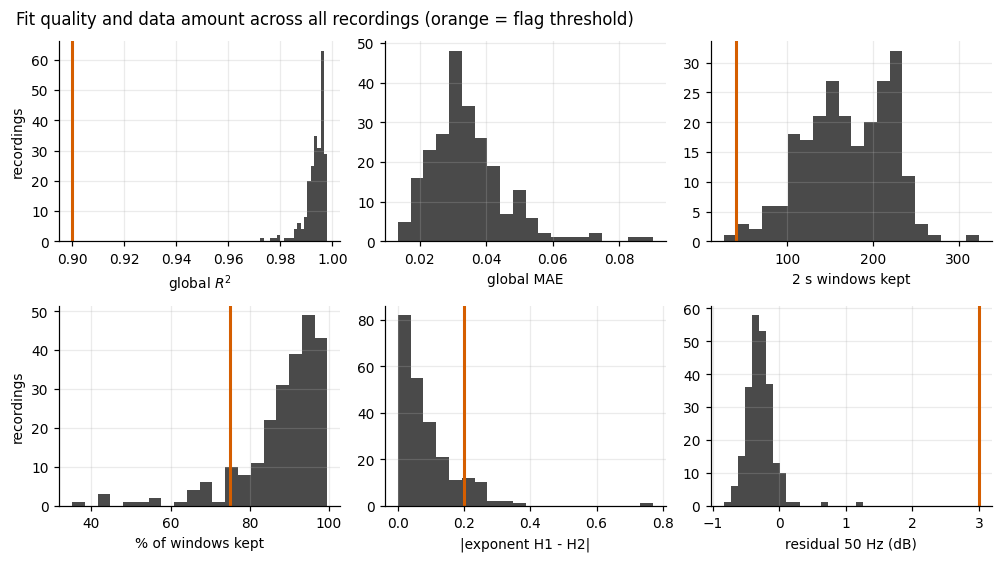

In [11]:
# distributions across all recordings
cols = [("R_Squared", "global $R^2$", R2_FLAG), ("Error_MAE", "global MAE", None),
        ("N_Windows", "2 s windows kept", MIN_WINDOWS),
        ("Pct_Windows_Kept", "% of windows kept", 75),
        ("Exponent_SplitDiff", "|exponent H1 - H2|", 0.2),
        ("Line50_dB", f"residual {LINE_FREQ:.0f} Hz (dB)", 3)]
fig, ax = plt.subplots(2, 3, figsize=(9, 5), constrained_layout=True)
for a, (col, lab, thr) in zip(ax.ravel(), cols):
    a.hist(qc[col].dropna(), bins=20, color="#4a4a4a")
    a.set_xlabel(lab)
    if thr is not None:
        a.axvline(thr, color="#D55E00", lw=2)
for a in ax[:, 0]:
    a.set_ylabel("recordings")
fig.suptitle("Fit quality and data amount across all recordings (orange = flag threshold)",
             ha="left", x=0.01)
plt.show()

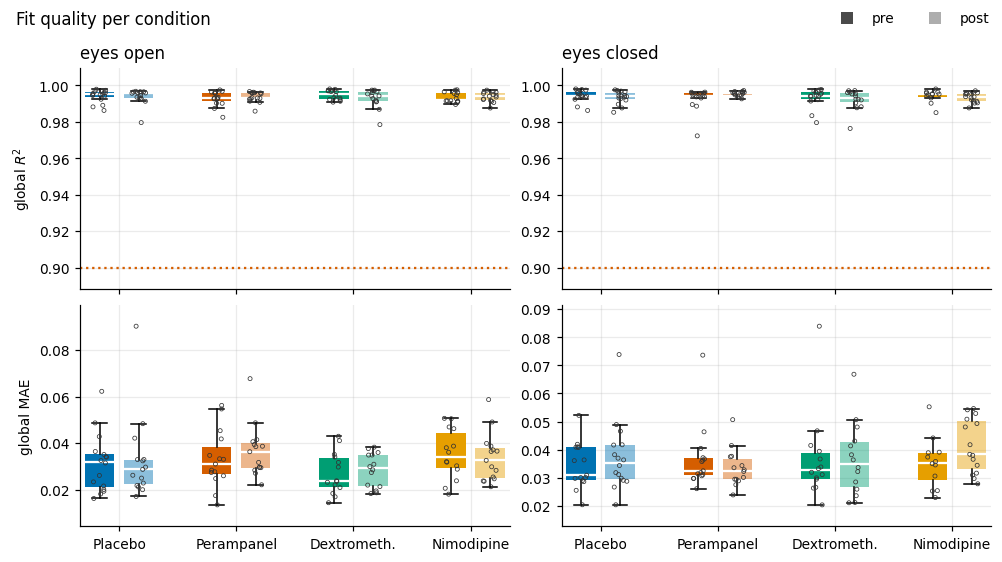

In [12]:
# fit quality per condition
fig, ax = plt.subplots(2, 2, figsize=(9, 5), sharex=True, constrained_layout=True)
for r, (col, lab, thr) in enumerate([("R_Squared", "global $R^2$", R2_FLAG),
                                     ("Error_MAE", "global MAE", None)]):
    for c, es in enumerate(["EO", "EC"]):
        box_by_condition(ax[r, c], col, lab if c == 0 else "", eyestate=es, hline=thr)
        if r == 0:
            ax[r, c].set_title(f"eyes {'open' if es == 'EO' else 'closed'}", loc="left")
fig.legend(handles=PREPOST_LEGEND, loc="outside upper right", ncol=2, frameon=False)
fig.suptitle("Fit quality per condition", ha="left", x=0.01)
plt.show()

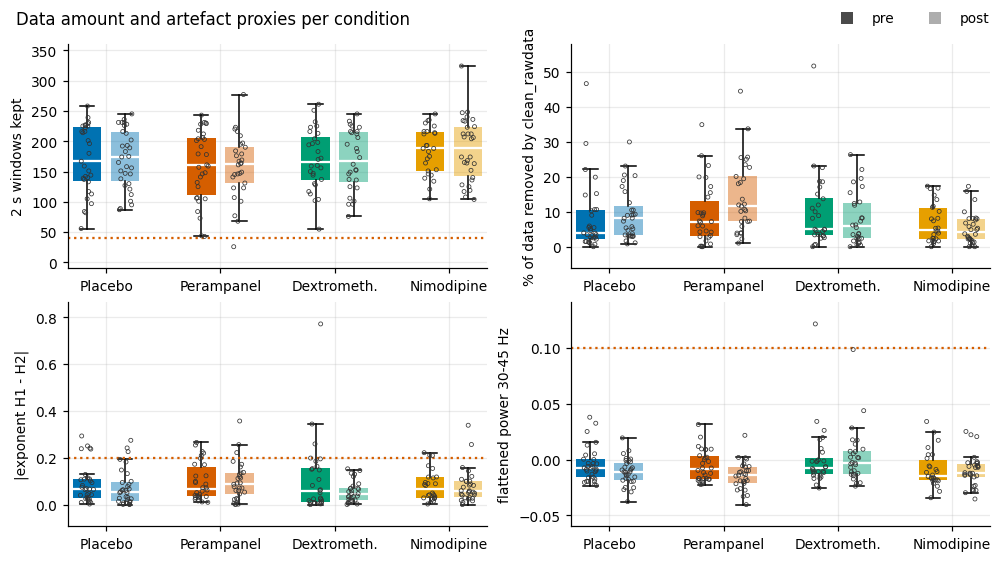

In [13]:
# data amount, cleaning and artefact proxies per condition (eye states pooled)
panels = [("N_Windows", "2 s windows kept", MIN_WINDOWS),
          ("Pct_Seconds_Removed" if "Pct_Seconds_Removed" in qc else "Pct_Windows_Kept",
           "% of data removed by clean_rawdata" if "Pct_Seconds_Removed" in qc
           else "% of windows kept", None),
          ("Exponent_SplitDiff", "|exponent H1 - H2|", 0.2),
          ("EMG_Flat_30_45", "flattened power 30-45 Hz", 0.1)]
fig, ax = plt.subplots(2, 2, figsize=(9, 5), constrained_layout=True)
for a, (col, lab, thr) in zip(ax.ravel(), panels):
    box_by_condition(a, col, lab, hline=thr)
fig.legend(handles=PREPOST_LEGEND, loc="outside upper right", ncol=2, frameon=False)
fig.suptitle("Data amount and artefact proxies per condition", ha="left", x=0.01)
plt.show()

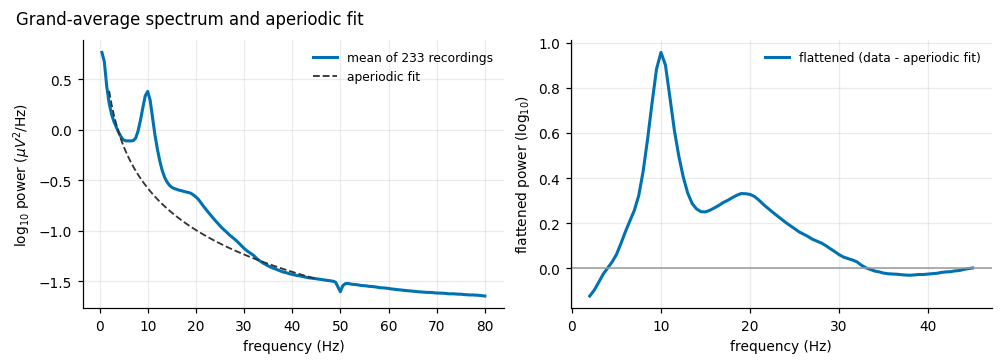

In [14]:
# grand average: spectrum + aperiodic fit, and the flattened spectrum
idx = np.arange(len(mats))
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2), constrained_layout=True)
ax[0].plot(freqs, logpsd[idx].mean(0), color="#0072B2", lw=2, label=f"mean of {len(idx)} recordings")
ax[0].plot(ffit, ap[idx].mean(0), color="#333333", lw=1.2, ls="--", label="aperiodic fit")
ax[0].set(xscale="linear", xlabel="frequency (Hz)", ylabel="log$_{10}$ power ($\\mu V^2$/Hz)")
ax[1].plot(ffit, flat[idx].mean(0), color="#0072B2", lw=2, label="flattened (data - aperiodic fit)")
ax[1].axhline(0, color="#999999", lw=1)
ax[1].set(xlabel="frequency (Hz)", ylabel="flattened power (log$_{10}$)")
for a in ax:
    a.legend(frameon=False, fontsize=8)
fig.suptitle("Grand-average spectrum and aperiodic fit", ha="left", x=0.01)
plt.show()

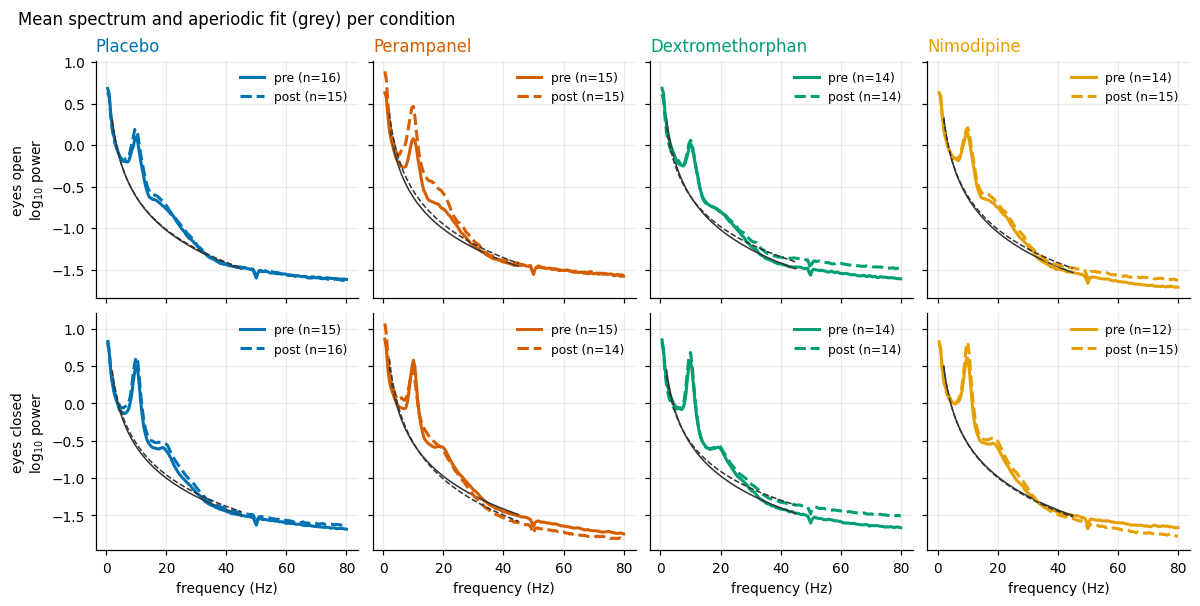

In [15]:
# per condition: mean spectrum (colour) with its aperiodic fit (grey), pre solid / post dashed
fig, ax = plt.subplots(2, len(drugs), figsize=(2.7 * len(drugs), 5.4), squeeze=False,
                       sharex=True, sharey="row", constrained_layout=True)
for r, es in enumerate(["EO", "EC"]):
    for c, d in enumerate(drugs):
        a = ax[r, c]
        for pp, ls in [("pre", "-"), ("post", "--")]:
            sel = key.index[(key.Drug == d) & (key.EyeState == es) & (key.PrePost == pp)]
            i = np.flatnonzero(np.isin(names, sel))
            if len(i) == 0:
                continue
            a.plot(freqs, logpsd[i].mean(0), color=DRUG_COLORS[d], lw=2, ls=ls,
                   label=f"{pp} (n={len(i)})")
            a.plot(ffit, ap[i].mean(0), color="#333333", lw=1, ls=ls)
        a.set_xscale("linear")
        a.legend(frameon=False, fontsize=8)
        if r == 0:
            a.set_title(d, loc="left", color=DRUG_COLORS[d])
        if c == 0:
            a.set_ylabel(f"{'eyes open' if es == 'EO' else 'eyes closed'}\nlog$_{{10}}$ power")
        if r == 1:
            a.set_xlabel("frequency (Hz)")
fig.suptitle("Mean spectrum and aperiodic fit (grey) per condition", ha="left", x=0.01)
plt.show()

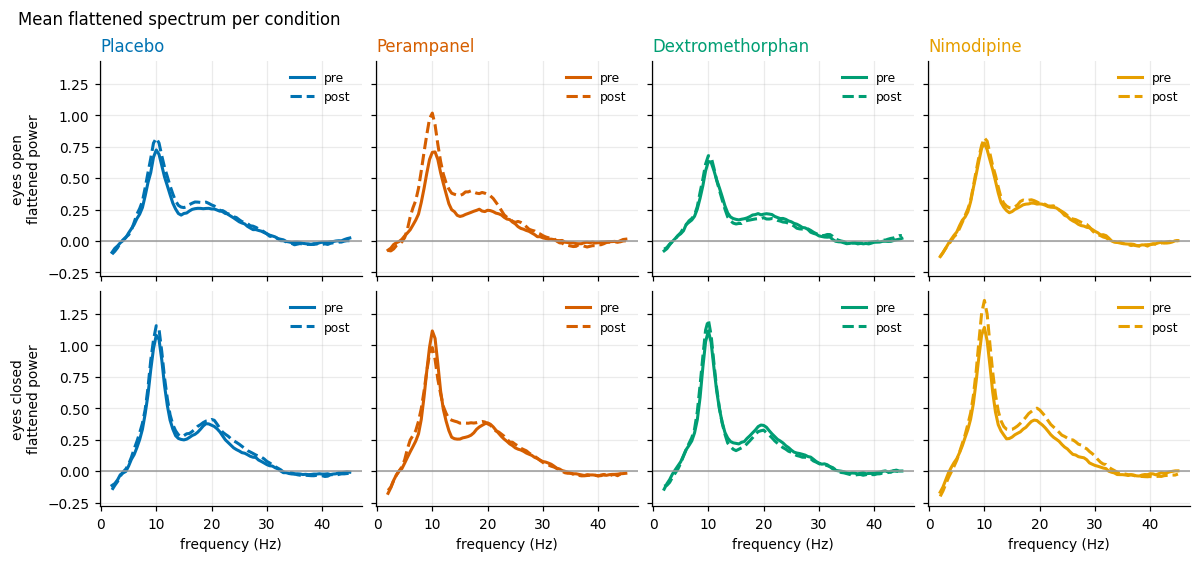

In [16]:
# per condition: flattened spectrum
fig, ax = plt.subplots(2, len(drugs), figsize=(2.7 * len(drugs), 5.0), squeeze=False,
                       sharex=True, sharey=True, constrained_layout=True)
for r, es in enumerate(["EO", "EC"]):
    for c, d in enumerate(drugs):
        a = ax[r, c]
        for pp, ls in [("pre", "-"), ("post", "--")]:
            sel = key.index[(key.Drug == d) & (key.EyeState == es) & (key.PrePost == pp)]
            i = np.flatnonzero(np.isin(names, sel))
            if len(i) == 0:
                continue
            a.plot(ffit, flat[i].mean(0), color=DRUG_COLORS[d], lw=2, ls=ls, label=pp)
        a.axhline(0, color="#999999", lw=1)
        a.legend(frameon=False, fontsize=8)
        if r == 0:
            a.set_title(d, loc="left", color=DRUG_COLORS[d])
        if c == 0:
            a.set_ylabel(f"{'eyes open' if es == 'EO' else 'eyes closed'}\nflattened power")
        if r == 1:
            a.set_xlabel("frequency (Hz)")
fig.suptitle("Mean flattened spectrum per condition", ha="left", x=0.01)
plt.show()